In [1]:
import pandas as pd
from sklearn.metrics import precision_score, accuracy_score, recall_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
df = pd.read_csv("loan.csv")

## Handing Missing Values

In [3]:
num_cols = df.select_dtypes(include = ["float64"]).columns
cat_cols = df.select_dtypes(include = ["object"]).columns


In [4]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = 'mean')
df[num_cols] = num_imp.fit_transform(df[num_cols])

cat_imp = SimpleImputer(strategy = 'most_frequent')
df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

In [5]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [6]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

## EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
classes_count = df["Loan_Approved"].value_counts()
classes_count

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

Text(0.5, 1.0, 'Is Loan Approved')

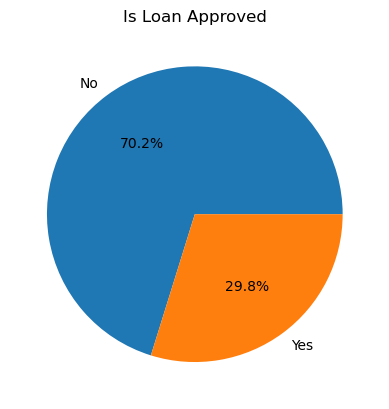

In [9]:
plt.pie(classes_count, labels = ["No" , "Yes"] , autopct = "%1.1f%%")
plt.title("Is Loan Approved")

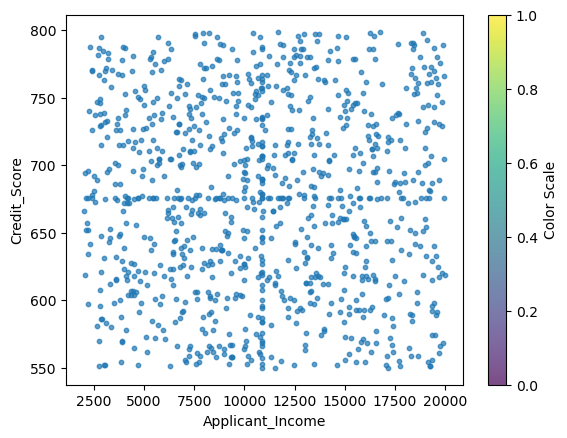

In [10]:

plt.scatter(x = df["Applicant_Income"] , y = df["Credit_Score"],s=10, 
 marker='o',
 alpha= 0.7 )
plt.xlabel("Applicant_Income")
plt.ylabel("Credit_Score")

plt.colorbar(label='Color Scale')
plt.show()

Text(0, 0.5, 'No. of People')

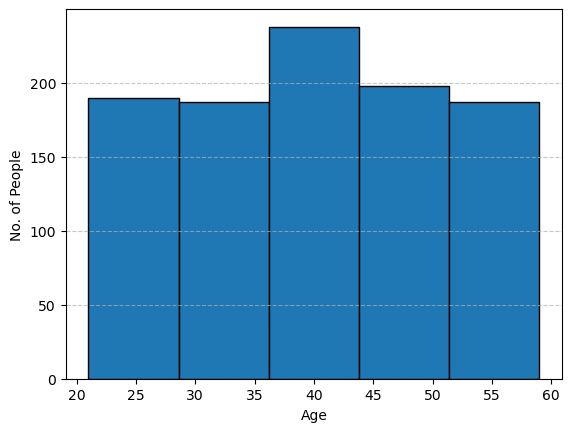

In [11]:
plt.hist(x = df["Age"] , edgecolor = 'black' , bins = 5 )
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xlabel("Age")
plt.ylabel("No. of People")

Text(0, 0.5, 'No. of People')

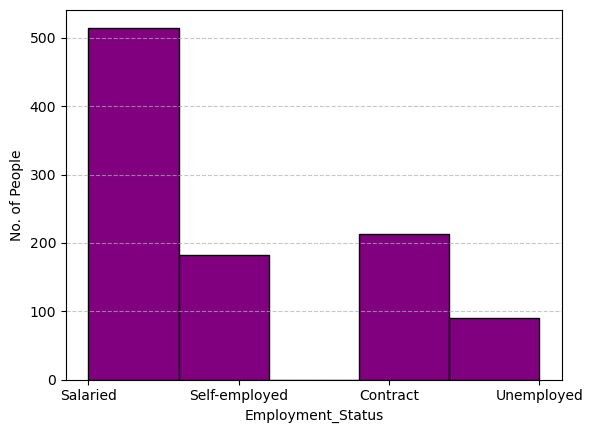

In [12]:
plt.hist(x = df["Employment_Status"] , edgecolor = 'black' , bins = 5 , color = "purple" )
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xlabel("Employment_Status")
plt.ylabel("No. of People")

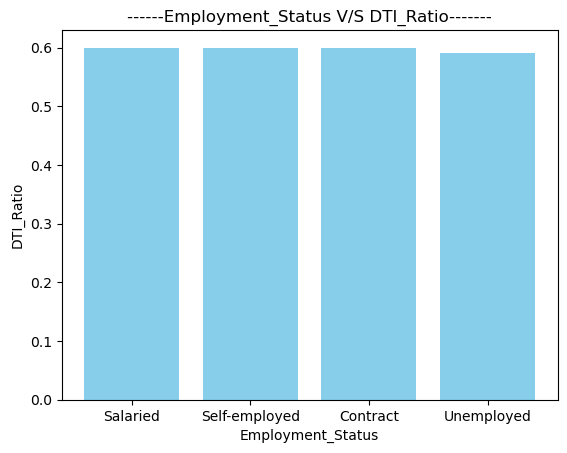

In [13]:

plt.bar(df["Employment_Status"], df["DTI_Ratio"],label = df["Loan_Approved"], color = "skyblue")
plt.xlabel("Employment_Status")
plt.ylabel("DTI_Ratio")
plt.title("------Employment_Status V/S DTI_Ratio-------")
plt.show()

In [14]:
df = df.drop("Applicant_ID",axis = 1)

In [15]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [16]:
df[cat_cols]

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...
995,Salaried,Married,Personal,Urban,Not Graduate,Male,Unemployed,No
996,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


In [17]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])


df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [18]:
cols = ['Employment_Status' , 'Loan_Purpose', 'Property_Area','Gender','Employer_Category','Marital_Status']

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop = "first",sparse_output=False , handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns = ohe.get_feature_names_out(cols),index = df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis =1)

In [19]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Marital_Status_Single
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


## Corelation Heatmap

In [20]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [21]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

## Corrleation Heatmap

<Axes: >

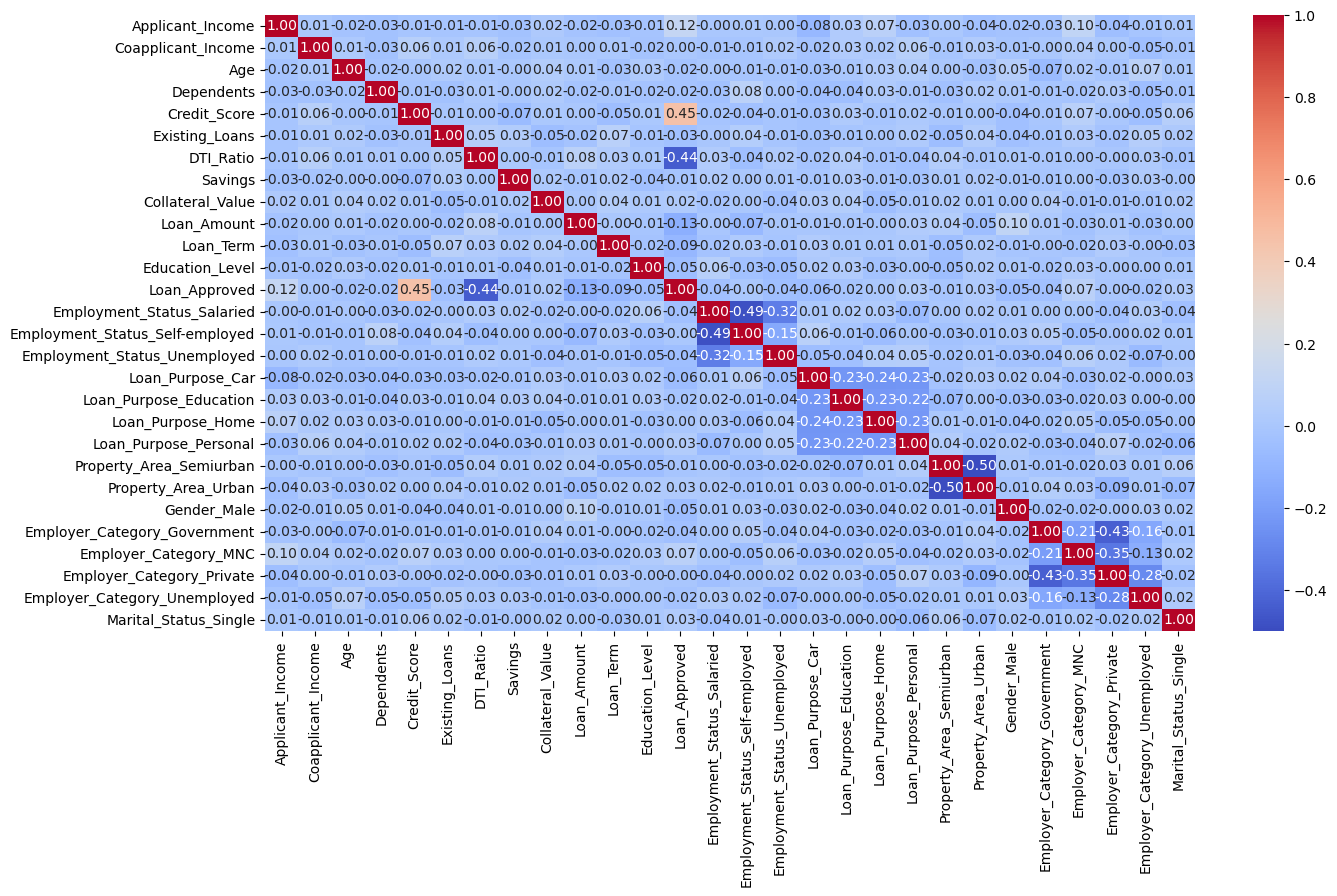

In [22]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.2f',
    cmap = "coolwarm"
)

## Train-test split + Feature Scaling

In [23]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



In [26]:
X_train_scaled

array([[ 1.07868611,  0.48046878,  1.09380121, ..., -0.86564846,
        -0.31362502,  1.39233491],
       [-1.29857296, -0.00795011, -0.00463674, ...,  1.15520335,
        -0.31362502, -0.71821801],
       [ 0.52710116,  1.33697734, -0.45864238, ..., -0.86564846,
        -0.31362502, -0.71821801],
       ...,
       [-0.23943379,  0.34961819, -0.82392323, ...,  1.15520335,
        -0.31362502,  1.39233491],
       [ 1.10730608, -0.47241898,  1.18512142, ..., -0.86564846,
        -0.31362502, -0.71821801],
       [-1.75589211,  0.010884  , -0.00204133, ..., -0.86564846,
        -0.31362502,  1.39233491]])

## Train & Evalute model

In [27]:
#Logistic regression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled , y_train)

y_pred = lr_model.predict(X_test_scaled)

print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Precision:  0.8674698795180723
recall:  0.6728971962616822
f1_score:  0.7578947368421053
accuracy:  0.8606060606060606
Confusion Matrix:  [[212  11]
 [ 35  72]]


In [28]:
#KNear Classifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))


Precision:  0.6716417910447762
recall:  0.4205607476635514
f1_score:  0.5172413793103449
accuracy:  0.7454545454545455
Confusion Matrix:  [[201  22]
 [ 62  45]]


In [29]:
#Naive Bayes
naive_byes = GaussianNB()
naive_byes.fit(X_train_scaled , y_train)

y_pred = naive_byes.predict(X_test_scaled)

print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))



Precision:  0.8780487804878049
recall:  0.6728971962616822
f1_score:  0.7619047619047619
accuracy:  0.8636363636363636
Confusion Matrix:  [[213  10]
 [ 35  72]]


# Best Model on the basis of Precision => Naive Bayes

### Feature Engineering

In [30]:
import numpy as np
# Add and Transdorm features
df["DTI_Ratio_sqr"] = df["DTI_Ratio"]**2
df["Credit_Score_sqr"] = df["Credit_Score"]**2

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

column = ["DTI_Ratio", "Credit_Score","Loan_Approved" , "Applicant_Income"]

X = df.drop(columns =column,axis = 1 )
y = df["Loan_Approved"]


# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)




In [31]:
#Logistic regression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled , y_train)

y_pred = lr_model.predict(X_test_scaled)

lr_precision = precision_score(y_test,y_pred)
lr_recall = recall_score(y_test,y_pred)
lr_f1_score = f1_score(y_test,y_pred)
lr_accuracy= accuracy_score(y_test,y_pred)


print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Precision:  0.8555555555555555
recall:  0.719626168224299
f1_score:  0.7817258883248731
accuracy:  0.8696969696969697
Confusion Matrix:  [[210  13]
 [ 30  77]]


In [32]:
#KNear Classifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

knn_precision = precision_score(y_test,y_pred)

knn_recall = recall_score(y_test,y_pred)
knn_f1_score = f1_score(y_test,y_pred)
knn_accuracy= accuracy_score(y_test,y_pred)

print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Precision:  0.704225352112676
recall:  0.4672897196261682
f1_score:  0.5617977528089888
accuracy:  0.7636363636363637
Confusion Matrix:  [[202  21]
 [ 57  50]]


In [33]:
#Naive Bayes
naive_byes = GaussianNB()
naive_byes.fit(X_train_scaled , y_train)

y_pred = naive_byes.predict(X_test_scaled)

nb_precision = precision_score(y_test,y_pred)


nb_recall = recall_score(y_test,y_pred)
nb_f1_score = f1_score(y_test,y_pred)
nb_accuracy= accuracy_score(y_test,y_pred)

print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Precision:  0.8735632183908046
recall:  0.7102803738317757
f1_score:  0.7835051546391752
accuracy:  0.8727272727272727
Confusion Matrix:  [[212  11]
 [ 31  76]]


In [34]:
results = {
    "Model": ["Logistic Regression", "KNN", "Naive Bayes"],
    "Precision": [lr_precision, knn_precision, nb_precision],
    "Recall": [lr_recall, knn_recall, nb_recall],
    "F1 Score": [lr_f1_score, knn_f1_score, nb_f1_score],
    "Accuracy": [lr_accuracy, knn_accuracy, nb_accuracy]
}

pd.DataFrame(results).sort_values("Precision", ascending=False )

,Model,Precision,Recall,F1 Score,Accuracy
2,Naive Bayes,0.873563,0.710280,0.783505,0.872727
0,Logistic Regression,0.855556,0.719626,0.781726,0.869697
1,KNN,0.704225,0.467290,0.561798,0.763636
